In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree


import smoothie
smoothie.suppress_warnings()

In [4]:
adata = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_raw_bin50.h5ad")

In [ ]:

coords = adata.obsm['spatial']

coords = np.array(coords, dtype=float)

tree = KDTree(coords)
rng = np.random.default_rng(42)
query_idx = rng.choice(len(coords), size=min(5000, len(coords)), replace=False)
dists, _ = tree.query(coords[query_idx], k=2)   # k=2: skip self (distance 0)
nn_dists = dists[:, 1]
bin_size_estimate = np.median(nn_dists)
print(f"Median nearest-neighbour distance (estimated bin size): {bin_size_estimate:.3f} coordinate units")
print(f"  min: {nn_dists.min():.3f}   max: {nn_dists.max():.3f}   std: {nn_dists.std():.3f}")

Median nearest-neighbour distance (estimated bin size): 50.000 coordinate units
  min: 50.000   max: 50.000   std: 0.000


In [11]:
# sc.pp.filter_cells(adata, min_counts=100)
# sc.pp.filter_genes(adata, min_counts=300)
# sc.pp.filter_genes(adata, min_cells=10)

# sc.pp.normalize_total(adata, target_sum=1e3)
# sc.pp.log1p(adata)

KeyboardInterrupt: 

In [14]:
print(adata.shape)

(662769, 49848)


In [ ]:
from scipy.sparse import issparse, csr_matrix
from smoothie.gaussian_smoothing import perform_density_check, run_gridbased_smoothing, run_inplace_smoothing

def run_parallelized_smoothing(adata,
                               grid_based_or_not,
                               gaussian_sd,
                               min_spots_under_gaussian,
                               stride=None,
                               grid_fitting_dist=None,
                               num_processes=10,
                               num_data_splits=None):
    assert hasattr(adata, "X"), "adata.X does not exist"
    assert adata.X.ndim == 2, "adata.X must be a 2D matrix"
    assert 'spatial' in adata.obsm, "'spatial' key is missing in adata.obsm"
    adata.obsm['spatial'] = np.array(adata.obsm['spatial'])
    assert np.array(adata.obsm['spatial']).ndim == 2, "adata.obsm['spatial'] must be a 2D array"

    if not adata.var_names.is_unique:
        raise ValueError(
            "Gene names (adata.var_names) are not unique. "
            "Please run `adata.var_names_make_unique()` before running this function."
        )

    assert isinstance(grid_based_or_not, bool), "grid_based_or_not must be True or False"
    assert isinstance(gaussian_sd, (int, float)) and gaussian_sd > 0, "gaussian_sd must be a positive number."
    assert isinstance(min_spots_under_gaussian, int) and min_spots_under_gaussian > 0, \
        "min_spots_under_gaussian must be a positive integer. (Range ~25-100)."

    if grid_based_or_not:
        if stride is None:
            stride = gaussian_sd
        assert isinstance(stride, (int, float)) and stride >= (0.5*gaussian_sd) and stride <= gaussian_sd, (
            "stride must be a value in the range [0.5 * gaussian_sd, 1.0 * gaussian_sd]. (Default is 1.0 * gaussian_sd)."
        )

    if grid_based_or_not:
        if grid_fitting_dist is None:
            grid_fitting_dist = 0.25 * gaussian_sd
        assert (isinstance(grid_fitting_dist, (int, float))
                and grid_fitting_dist >= (0.25*gaussian_sd)
                and grid_fitting_dist <= (0.5*gaussian_sd)), (
            "grid_fitting_dist must be a value in the range [0.25 * gaussian_sd, 0.5 * gaussian_sd]. (Default is 0.25 * gaussian_sd)."
        )

    assert isinstance(num_processes, int) and num_processes > 0, (
        "num_processes must be a positive integer. (Default is 10)."
    )

    if num_data_splits is not None:
        assert isinstance(num_data_splits, int) and num_data_splits > 0, (
            "num_data_splits must be a positive integer. (Default is 1 to 6)."
        )
    if num_data_splits is None:
        locs = adata.shape[0]
        if float(locs) < 100000:
            num_data_splits = 2
        elif float(locs) < 1000000:
            num_data_splits = 4
        else:
            num_data_splits = 6

    if issparse(adata.X):
        adata.X = adata.X.tocsr()
    else:
        adata.X = csr_matrix(adata.X)

    kernel_radius = 3 * gaussian_sd

    if grid_based_or_not:
        perform_density_check(adata, grid_based_or_not, gaussian_sd, min_spots_under_gaussian,
                              stride, grid_fitting_dist, num_data_splits)
        sm_adata = run_gridbased_smoothing(adata, stride, grid_fitting_dist, min_spots_under_gaussian,
                                           gaussian_sd, kernel_radius, num_processes, num_data_splits)
    else:
        locs, genes = adata.shape
        memory_estimation_gb = float(locs * genes * 4) / 1e9
        print(f"Storage for smoothed count matrix will be {memory_estimation_gb:.2f} GB.")
        # assert memory_estimation_gb < 100, "Memory usage will be high (>100GB)! Consider grid-based smoothing."

        perform_density_check(adata, grid_based_or_not, gaussian_sd, min_spots_under_gaussian,
                              stride=None, grid_fitting_dist=None, num_data_splits=num_data_splits)
        sm_adata = run_inplace_smoothing(adata, min_spots_under_gaussian, gaussian_sd,
                                         kernel_radius, num_processes, num_data_splits)

    gene_sums = np.sum(sm_adata.X, axis=0)
    zero_genes_mask = gene_sums == 0
    if np.any(zero_genes_mask):
        dropped_genes = sm_adata.var_names[zero_genes_mask]
        print("The following genes were removed because of weak signal in the dataset:")
        for gene in dropped_genes:
            print(f"{gene}")
        sm_adata = sm_adata[:, ~zero_genes_mask]

    return sm_adata

In [5]:
target_microns = 40.0
micron_to_unit_conversion = 2
sm_adata = run_parallelized_smoothing(
    adata,
    grid_based_or_not=False,
    gaussian_sd=target_microns * micron_to_unit_conversion,
    min_spots_under_gaussian=10
)

sm_adata.write_h5ad("../data/GSM9629357_CS23_E2S1_smooth_bin50.h5ad")

Storage for smoothed count matrix will be 132.15 GB.
Checking dataset point density...
Gaussian smoothing will run in 16 chunks.
Smoothing chunk: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
Total runtime for in-place Gaussian smoothing: 546.52 seconds.

The following genes were removed because of weak signal in the dataset:
AC270107.7
AC004675.2
AC256309.1
AC007876.1
TSPY5P
AC007275.1
MIR892B
CT45A3
RNU6-1323P
AL031183.1
GAGE2E
NANOGP10
AC005297.3
FUNDC2P4
RNU6-331P
DNAJA1P6
AL133493.2
KRTAP21-4P
AP000474.1
C1QBPP1
FEM1AP1
CR392039.3
AL096828.5
LINC01441
VN1R4
AC008507.3
AC011494.1
MIR3189
CYP4F36P
MAGEA1
AC091027.1
AP005380.1
AC068531.1
RNU2-69P
RNY4P13
VN1R71P
OR1AC1P
AC018695.3
AGGF1P9
AC009033.1
AC005632.1
RN7SL484P
AC067805.1
MTND1P9
TMPOP1
LINC02490
GOLGA8T
MIR548AV
AL162151.1
RNU6-976P
NMNAT1P1
AL357153.4
AL355834.1
AL356596.1
PSME1
OR4M1
AL159158.1
MTCL1P1
AC091132.2
LINC01058
PRUNEP1
LINC00421
AC084291.1
AC010183.1
TRAV27
AC139697.1
AC093027.1
AKIRIN1P1
AL031726.2


In [ ]:
sm_data = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_smooth_bin50.h5ad")
pearsonR_mat, _ = smoothie.compute_correlation_matrix(sm_adata.X)


compute_correlation_matrix running...
Total runtime for compute_correlation_matrix: 3281.47 seconds.



Running network clustering with parameters:
PCC hard cutoff: 0.3, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.4, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.5, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.6, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.7, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.8, clustering soft power: 1, 3, 5, 7, 9, 


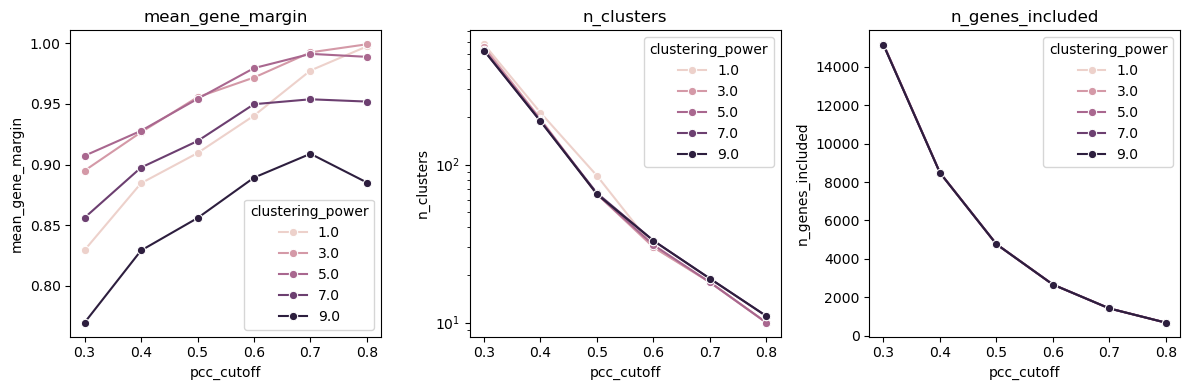

In [18]:
smoothie.select_clustering_params(
    gene_names=sm_adata.var_names,
    pearsonR_mat=pearsonR_mat,
    output_folder=None,
    pcc_cutoffs=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

In [20]:
edge_list, node_label_df = smoothie.make_spatial_network(
    pearsonR_mat=pearsonR_mat, # don't change
    gene_names=sm_adata.var_names, # don't change
    pcc_cutoff=0.4,
    clustering_power=3,
    output_folder='../Cytoscape'
)

# Filter node_label_df for only genes within modules of size 2 or more.
modules_df = node_label_df.groupby('module_label').filter(lambda x: len(x) >= 2)

# Examine modules
modules_df

,name,module_label,degree,weighted_degree,rescaled_weighted_degree,clustering_coeff,margin_score
0,STMN2,1,625,342.586293,33.445733,0.242113,0.896036
1,TUBB2B,1,673,361.609146,30.180883,0.223524,0.537882
2,AC092143.1,1,621,334.714117,29.329915,0.253161,0.712656
3,MAP2,1,611,327.827646,26.263113,0.258271,0.695384
4,RTN1,1,571,310.127194,25.752309,0.275251,0.954641
...,...,...,...,...,...,...,...
8483,RNU6-229P,1987,1,0.514662,0.006979,0.000000,1.000000
8484,AC091180.1,1988,1,0.450096,0.000582,0.000000,1.000000
8485,AC010975.2,1988,1,0.450096,0.000582,0.000000,1.000000
8486,AC115115.1,1989,1,0.537364,0.012000,0.000000,1.000000
